# 09 – Ciclo Brayton de Turbina de Gas

El **ciclo Brayton** es la columna vertebral termodinámica de los motores de
turbina de gas para generación de potencia y propulsión a chorro. La
idealización de aire estándar comprende cuatro procesos:

1. **Compresión isentrópica** (compresor): $P_1 \to P_2 = r_p P_1$
2. **Adición de calor isobárica** (cámara de combustión): $T_2 \to T_3$
3. **Expansión isentrópica** (turbina): $P_3 \to P_4 = P_3 / r_p$
4. **Rechazo de calor isobárico** (escape)

El análisis de libros de texto asume $C_p$ y $\gamma = C_p/C_v$ constantes,
dando la conocida eficiencia $\eta = 1 - r_p^{(1-\gamma)/\gamma}$. Aquí usamos
el $C_p(T)$ y $S^\circ(T)$ **reales** de `pyglenn` — el fluido de trabajo es
una mezcla de gas real de O₂ y N₂ (aire) — y resolvemos numéricamente la
condición isentrópica $S(T_2) = S(T_1)$.

La eficiencia térmica sigue directamente de los valores de entalpía en cada
estado:

$$\eta = 1 - \frac{H_4 - H_1}{H_3 - H_2}.$$

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Universal gas constant R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from scipy.optimize import brentq

## 1. Aire como fluido de trabajo

Modelamos el aire seco como la mezcla $1\ \mathrm{O_2} + 3{,}76\ \mathrm{N_2}$.
A continuación, las funciones para entalpía y entropía de la mezcla.

In [3]:
AIR = {"O2": 1.0, "N2": 3.76}
R_UNIV = R  # J/(mol·K) — constante universal de los gases

def air_enthalpy(calc, T):
    """Entalpía estandarizada total de 1 mol de aire a T, en J."""
    return sum(n * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]
               for name, n in AIR.items())

def air_entropy_std(calc, T):
    """Entropía en estado estándar (P=1 bar) de 1 mol de aire a T, en J/K."""
    return sum(n * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["s"]
               for name, n in AIR.items())

AIR_MOLES = sum(AIR.values())  # = 4.76


## 2. Relación isentrópica con $C_p(T)$ real

Para un gas ideal, la entropía molar en $(T,P)$ es

$$s(T,P) = s^\circ(T) - R \ln\frac{P}{P_0}.$$

Para un proceso **isentrópico** ($s_2 = s_1$) entre las presiones $P_1$ y $P_2$,
los términos de presión dan $s^\circ(T_2) - s^\circ(T_1) = R\ln(P_2/P_1)$.
Resolvemos

$$f(T) = s^\circ(T) - s^\circ(T_1) - R \ln\frac{P_2}{P_1} = 0$$

para $T_2$ con un buscador de raíz robusto con intervalo, contabilizando los
moles totales de la mezcla de aire.

In [4]:
def isentropic_T(calc, T1, P_ratio):
    """Temperatura tras compresión/expansión isentrópica (P2/P1 = P_ratio).

    Devuelve T2 [K] tal que s°(T2) - s°(T1) = R_aire * ln(P2/P1),
    donde R_aire = R × (moles totales de la mezcla).
    """
    s1 = air_entropy_std(calc, T1)
    R_air = R_UNIV * AIR_MOLES  # J/K por mol de mezcla de aire
    target = s1 + R_air * np.log(P_ratio)

    def f(T):
        return air_entropy_std(calc, T) - target

    if P_ratio > 1:
        lo, hi = T1, T1 * (P_ratio ** 0.4 + 1)
    else:
        lo, hi = T1 * P_ratio ** 0.4, T1

    while f(lo) * f(hi) > 0:
        if P_ratio > 1:
            hi *= 1.3
        else:
            lo *= 0.7
        if hi > 6000 or lo < 50:
            raise RuntimeError(f"No se pudo acotar T2 para P_ratio={P_ratio}")

    return brentq(f, lo, hi)


## 3. Construyendo el ciclo Brayton

Definimos los parámetros del ciclo:
- Entrada: $T_1 = 300\ \mathrm{K}$, $P_1 = 1\ \mathrm{bar}$
- Relación de presión: $r_p = P_2/P_1 = 10$
- Temperatura de entrada a la turbina (TIT): $T_3 = 1400\ \mathrm{K}$

Los cuatro estados se calculan con $C_p(T)$ real vía el solver isentrópico.

In [5]:
def brayton_states(calc, T1, T3, rp):
    """Devuelve dict de (T, h_por_kg_aire) para los cuatro estados Brayton.

    Los valores de h están en kJ por kg de aire (no por mol de mezcla).
    """
    M_O2 = 31.9988   # g/mol
    M_N2 = 28.0134   # g/mol
    M_air = (AIR["O2"] * M_O2 + AIR["N2"] * M_N2) / AIR_MOLES  # g/mol

    T2 = isentropic_T(calc, T1, rp)          # salida del compresor
    T4 = isentropic_T(calc, T3, 1.0 / rp)    # salida de la turbina

    def h_kJ_kg(T):
        return air_enthalpy(calc, T) / (M_air * 1e-3) / 1000  # kJ/kg

    return {
        "1 (entrada del compresor)":  (T1, h_kJ_kg(T1)),
        "2 (salida del compresor)":   (T2, h_kJ_kg(T2)),
        "3 (entrada de la turbina)":  (T3, h_kJ_kg(T3)),
        "4 (salida de la turbina)":   (T4, h_kJ_kg(T4)),
    }

with ThermochemicalCalculator() as calc:
    states = brayton_states(calc, T1=300.0, T3=1400.0, rp=10)

print(f"{'Estado':<28s} {'T [K]':>8s} {'h [kJ/kg]':>12s}")
print("-" * 48)
for label, (T, h) in states.items():
    print(f"{label:<28s} {T:8.1f} {h:12.2f}")


Estado                          T [K]    h [kJ/kg]
------------------------------------------------
1 (entrada del compresor)       300.0         8.91
2 (salida del compresor)        573.1      1344.35
3 (entrada de la turbina)      1400.0      5834.55
4 (salida de la turbina)        789.3      2453.76


## 4. Eficiencia térmica

$$\eta_\mathrm{th} = \frac{w_\mathrm{neto}}{q_\mathrm{entra}}
  = \frac{(h_3 - h_4) - (h_2 - h_1)}{h_3 - h_2}
  = 1 - \frac{h_4 - h_1}{h_3 - h_2}.$$

Comparamos el resultado con gas real y la fórmula de libro de texto con
$\gamma$ constante ($\gamma \approx 1{,}4$ para aire diatómico).

In [6]:
T1, h1 = states["1 (entrada del compresor)"]
T2, h2 = states["2 (salida del compresor)"]
T3, h3 = states["3 (entrada de la turbina)"]
T4, h4 = states["4 (salida de la turbina)"]

w_comp = h2 - h1          # trabajo del compresor [kJ/kg]
w_turb = h3 - h4          # trabajo de la turbina [kJ/kg]
q_in   = h3 - h2          # calor añadido [kJ/kg]
eta_real = (w_turb - w_comp) / q_in

gamma = 1.4
rp = 10
eta_cold = 1 - rp ** ((1 - gamma) / gamma)

print(f"Eficiencia Brayton gas real    : {eta_real:.4f} ({eta_real*100:.1f}%)")
print(f"Aire frío estándar (gamma=1,4)  : {eta_cold:.4f} ({eta_cold*100:.1f}%)")
print(f"Trabajo de la turbina  : {w_turb:.1f} kJ/kg")
print(f"Trabajo del compresor  : {w_comp:.1f} kJ/kg")
print(f"Trabajo neto           : {w_turb - w_comp:.1f} kJ/kg")


Eficiencia Brayton gas real    : 0.4555 (45.6%)
Aire frío estándar (gamma=1,4)  : 0.4821 (48.2%)
Trabajo de la turbina  : 3380.8 kJ/kg
Trabajo del compresor  : 1335.4 kJ/kg
Trabajo neto           : 2045.3 kJ/kg


## 5. Diagrama T–s (cualitativo)

Esbozamos los cuatro estados en ejes temperatura–entropía, usando la entropía
estándar de la mezcla de aire a la presión de cada estado.

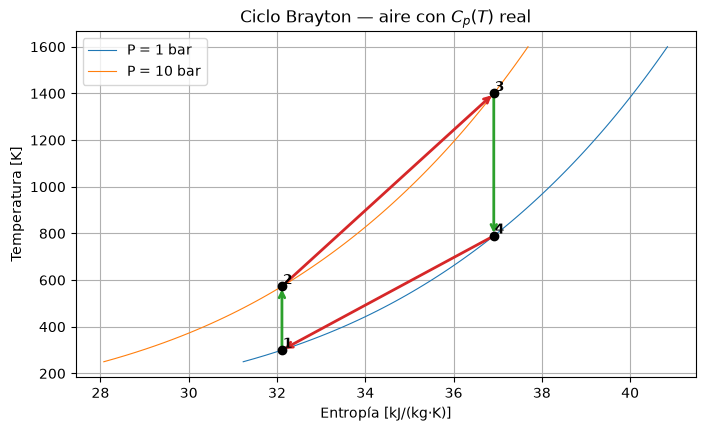

In [7]:
def air_s_at_P(calc, T, P_bar):
    """Entropía de la mezcla de aire en (T, P), en kJ/(kg·K)."""
    s_std = air_entropy_std(calc, T)
    R_air = R_UNIV * AIR_MOLES
    s_p = s_std - R_air * np.log(P_bar / 1.0)
    M_air = (AIR["O2"] * 31.9988 + AIR["N2"] * 28.0134) / AIR_MOLES
    return s_p / (M_air * 1e-3) / 1000

rp = 10
T1_val, T3_val = 300.0, 1400.0

with ThermochemicalCalculator() as calc:
    T2_val = isentropic_T(calc, T1_val, rp)
    T4_val = isentropic_T(calc, T3_val, 1.0 / rp)

    T_range = np.linspace(250, 1600, 100)
    s_low   = np.array([air_s_at_P(calc, T, 1)  for T in T_range])
    s_high  = np.array([air_s_at_P(calc, T, 10) for T in T_range])

    s1 = air_s_at_P(calc, T1_val, 1)
    s2 = air_s_at_P(calc, T2_val, 10)
    s3 = air_s_at_P(calc, T3_val, 10)
    s4 = air_s_at_P(calc, T4_val, 1)

fig, ax = plt.subplots()
ax.plot(s_low,  T_range, "C0", lw=0.8, label="P = 1 bar")
ax.plot(s_high, T_range, "C1", lw=0.8, label="P = 10 bar")
ax.annotate("", xy=(s2, T2_val), xytext=(s1, T1_val),
            arrowprops=dict(arrowstyle="->", color="C2", lw=2))
ax.annotate("", xy=(s3, T3_val), xytext=(s2, T2_val),
            arrowprops=dict(arrowstyle="->", color="C3", lw=2))
ax.annotate("", xy=(s4, T4_val), xytext=(s3, T3_val),
            arrowprops=dict(arrowstyle="->", color="C2", lw=2))
ax.annotate("", xy=(s1, T1_val), xytext=(s4, T4_val),
            arrowprops=dict(arrowstyle="->", color="C3", lw=2))
ax.scatter([s1, s2, s3, s4], [T1_val, T2_val, T3_val, T4_val],
           color="black", zorder=5)
for i, (s, T, lbl) in enumerate([(s1, T1_val, "1"), (s2, T2_val, "2"),
                                  (s3, T3_val, "3"), (s4, T4_val, "4")]):
    ax.text(s + 0.02, T + 10, lbl, fontweight="bold")
ax.set_xlabel("Entropía [kJ/(kg·K)]")
ax.set_ylabel("Temperatura [K]")
ax.set_title("Ciclo Brayton — aire con $C_p(T)$ real")
ax.legend()
plt.show()


## 6. Eficiencia vs. relación de presión: real vs. aire frío estándar

La fórmula de aire frío estándar $\eta = 1 - r_p^{(1-\gamma)/\gamma}$ predice
eficiencia monótonamente creciente. Con $C_p(T)$ real, la curva de eficiencia
tiene forma similar pero está desplazada porque $\gamma(T)$ disminuye al subir
la temperatura (los modos vibracionales se activan), haciendo el compresor "más
rígido" y la turbina menos efectiva a relaciones de presión más altas de lo que
la aproximación de aire frío sugiere.

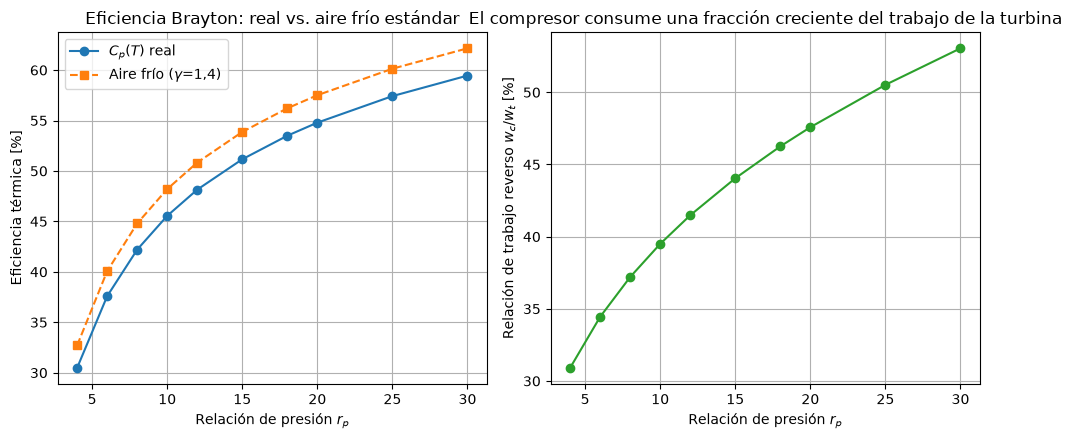

In [8]:
rp_range = np.array([4, 6, 8, 10, 12, 15, 18, 20, 25, 30])
eta_real_list, eta_cold_list, backwork_list = [], [], []

with ThermochemicalCalculator() as calc:
    for rp in rp_range:
        st = brayton_states(calc, T1=300.0, T3=1400.0, rp=rp)
        _, h1 = st["1 (entrada del compresor)"]
        _, h2 = st["2 (salida del compresor)"]
        _, h3 = st["3 (entrada de la turbina)"]
        _, h4 = st["4 (salida de la turbina)"]
        w_comp = h2 - h1
        w_turb = h3 - h4
        q_in   = h3 - h2
        eta_real_list.append((w_turb - w_comp) / q_in * 100)
        eta_cold_list.append((1 - rp ** ((1 - 1.4) / 1.4)) * 100)
        backwork_list.append(w_comp / w_turb * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

ax1.plot(rp_range, eta_real_list, "o-", label="$C_p(T)$ real")
ax1.plot(rp_range, eta_cold_list, "s--", label=r"Aire frío ($\gamma$=1,4)")
ax1.set_xlabel("Relación de presión $r_p$")
ax1.set_ylabel("Eficiencia térmica [%]")
ax1.set_title("Eficiencia Brayton: real vs. aire frío estándar")
ax1.legend()

ax2.plot(rp_range, backwork_list, "o-", color="C2")
ax2.set_xlabel("Relación de presión $r_p$")
ax2.set_ylabel("Relación de trabajo reverso $w_c / w_t$ [%]")
ax2.set_title("El compresor consume una fracción creciente del trabajo de la turbina")

plt.tight_layout()
plt.show()


## Resumen

- $C_p(T)$ real de `pyglenn` permite un análisis preciso del ciclo Brayton sin
  asumir $\gamma$ constante.
- La condición isentrópica $s^\circ(T_2) = s^\circ(T_1) + R\ln(P_2/P_1)$ se
  resuelve numéricamente para cada proceso.
- La curva de eficiencia real es cercana pero distinta del ideal de aire frío;
  la diferencia crece a relaciones de presión más altas donde $\gamma(T)$ se
  desvía de 1,4.
- La relación de trabajo reverso crece con $r_p$, limitando las relaciones de
  presión prácticas para motores de un solo eje.

**A continuación:** el cuaderno 10 muestra cómo usar `pyglenn` como proveedor de
propiedades de alto rendimiento para códigos de CFD y cinética química.